# 01 · Advanced EDA — Distributions, Outliers, Association

## Part 1 — Advanced EDA (the basics, done properly)

The discipline of *looking before modelling*. We run, on real data:

1. The **four moments** and the **four-view battery** (hist+KDE · box · ECDF · Q–Q)
2. The **normality battery** — and what *fat tails* actually look like
3. **Transformations** (when and why to log)
4. **Outliers** — robust detection, and *investigate before you delete*
5. **Correlation** three ways (Pearson / Spearman / Kendall) + **mutual information**
6. **Multicollinearity** via **VIF**
7. **Categorical association** (chi-square, Cramér's V)
8. **Missing-data mechanisms** (MCAR / MAR / MNAR)

Financial returns drive the distribution lessons; Telco drives the categorical/collinearity lessons.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

telco = data.clean_telco()
shiller = data.clean_shiller()
ret = shiller['return'].dropna()
print('returns:', ret.size, '| telco:', telco.shape)

setup ok | numpy 2.1.3 | pandas 2.3.3
returns: 1864 | telco: (7043, 21)


### 1. The four moments + the four-view battery

Never trust a single number. `describe()` hides shape — two variables with the same mean and
std can look completely different. The battery shows **shape** (hist), **spread & outliers**
(box), **percentiles** (ECDF), and **normality** (Q–Q) at once.

n                  1864.0000
mean                  0.0048
std                   0.0405
skew                  0.3727
excess_kurtosis      16.7205
min                  -0.2647
median                0.0070
max                   0.5030


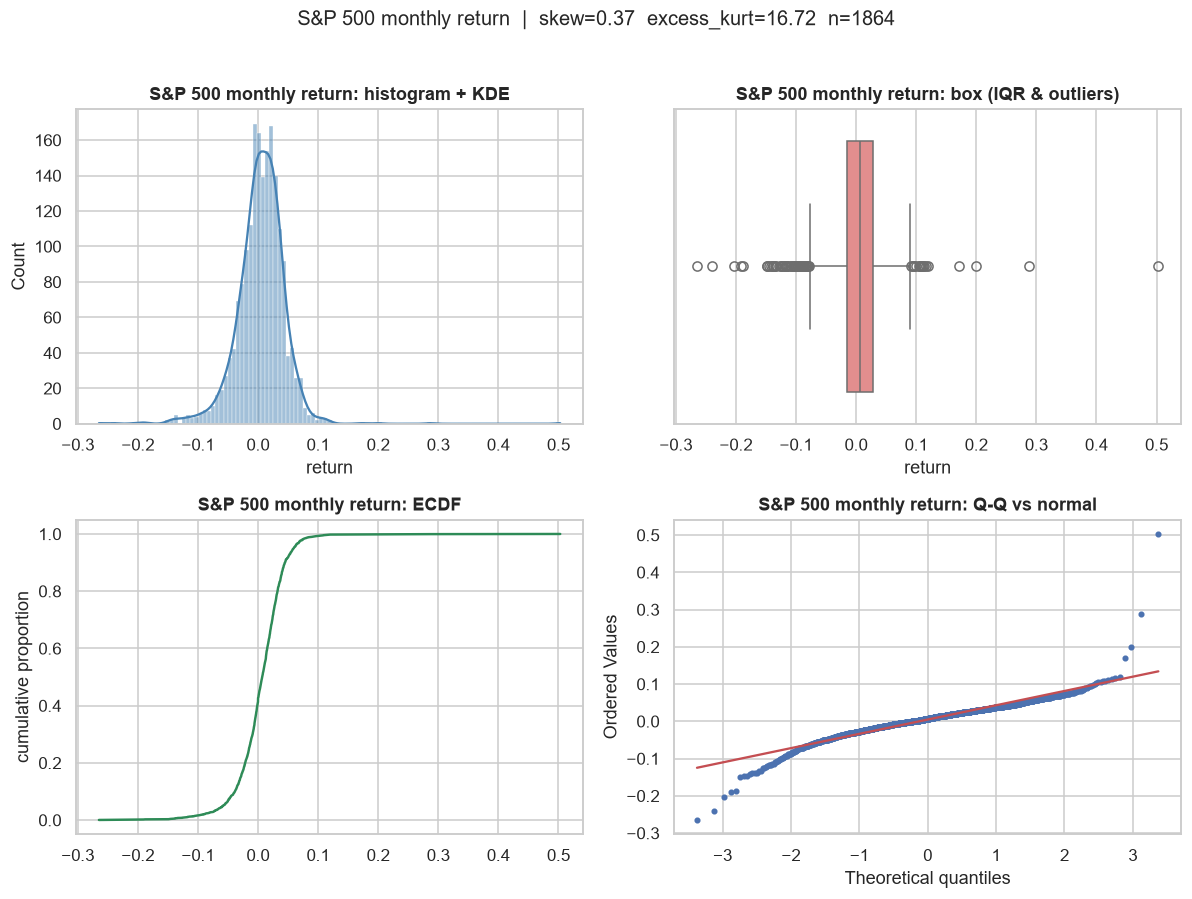

In [2]:
print(eda.moments(ret).round(4).to_string())
fig = eda.four_view(ret, "S&P 500 monthly return", "p1_fourview_returns.png")
plt.show()

Read the Q–Q panel: the points fly off the line at both ends — far more extreme months than
a normal distribution allows. That bend *is* fat tails. The box plot's swarm of "outliers" are
not errors either (next section).

Same battery on a Telco numeric — `MonthlyCharges` is **bimodal** (two customer populations), which a mean/std summary would completely hide:

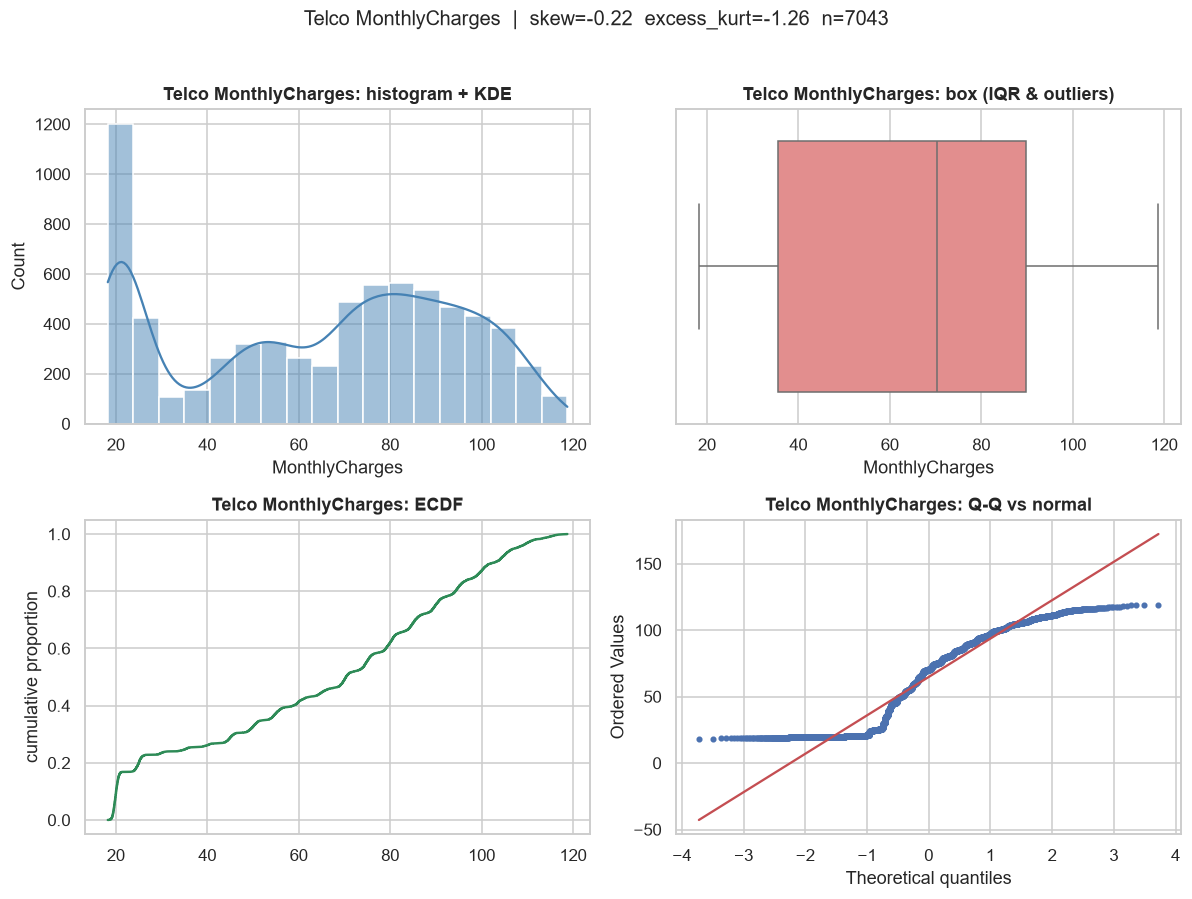

In [3]:
fig = eda.four_view(telco["MonthlyCharges"], "Telco MonthlyCharges", "p1_fourview_monthlycharges.png")
plt.show()

### 2. Normality battery — quantifying the fat tails

Excess kurtosis is **0** for a normal distribution. Markets sit near **+17**: extreme moves
happen far more often than a bell curve predicts — the single fact entire risk models are built around.

          test  statistic  p_value  normal_at_5pct
   Jarque-Bera 21632.1549      0.0           False
D'Agostino K^2   475.7516      0.0           False
  Shapiro-Wilk     0.8994      0.0           False

excess kurtosis = 16.72   (normal = 0)


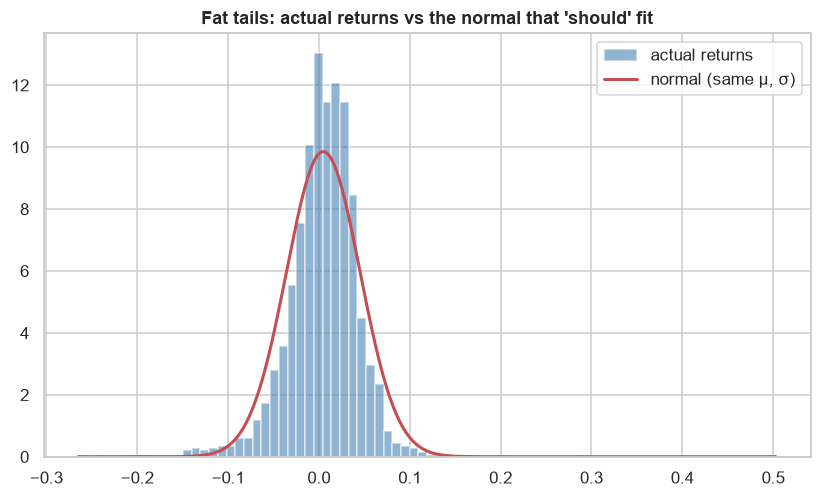

In [4]:
print(eda.normality_battery(ret).round(4).to_string(index=False))
print("\nexcess kurtosis = %.2f   (normal = 0)" % ret.kurt())

# Overlay a fitted normal to make the gap visible.
from scipy import stats
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ret, bins=80, density=True, alpha=0.6, color="steelblue", label="actual returns")
xs = np.linspace(ret.min(), ret.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, ret.mean(), ret.std()), "r-", lw=2, label="normal (same μ, σ)")
ax.set_title("Fat tails: actual returns vs the normal that 'should' fit"); ax.legend()
eda.savefig(fig, "p1_fat_tails.png"); plt.show()

### 3. Transformations — when to log

Right-skewed, multiplicative, strictly-positive quantities (prices, money, weights) are often
**log-normal**. Logging turns multiplicative structure additive and pulls in the tail. The S&P
price level is the textbook case.

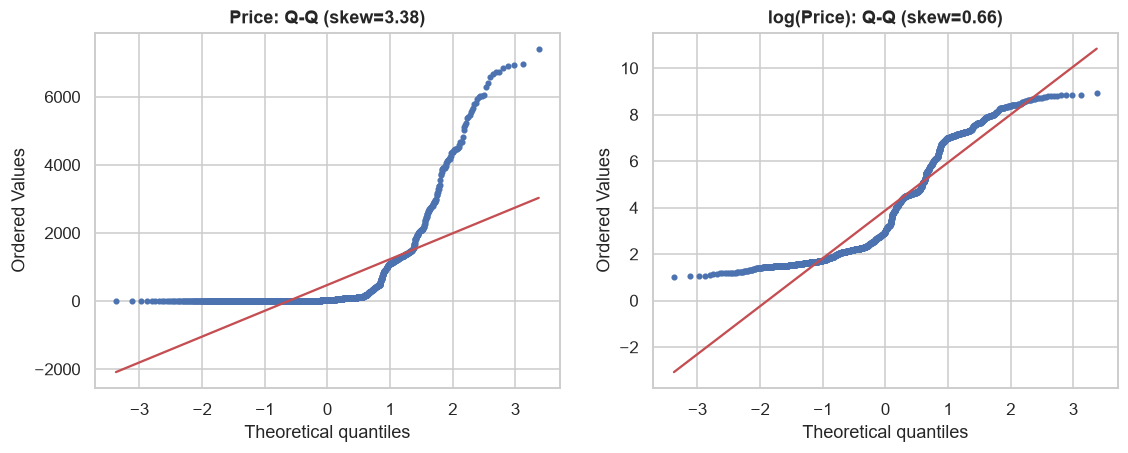

skew  price = 3.38   ->   log(price) = 0.66


In [5]:
price = shiller["SP500"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
stats.probplot(price, dist="norm", plot=ax[0]); ax[0].set_title(f"Price: Q-Q (skew={price.skew():.2f})")
stats.probplot(np.log(price), dist="norm", plot=ax[1]); ax[1].set_title(f"log(Price): Q-Q (skew={np.log(price).skew():.2f})")
for a in ax: a.get_lines()[0].set_markersize(3)
eda.savefig(fig, "p1_log_transform.png"); plt.show()
print("skew  price = %.2f   ->   log(price) = %.2f" % (price.skew(), np.log(price).skew()))

### 4. Outliers — detect robustly, then *investigate*

Two robust flags: **Tukey 1.5×IQR** fences and the **MAD-based modified z** (|z|>3.5). MAD is
robust because it does not let the outliers inflate the very scale used to detect them.

In [6]:
print(eda.outlier_flags(ret).round(2).to_string(index=False))

extreme = ret.reindex(ret.abs().sort_values(ascending=False).index).head(6)
print("\nThe 6 most extreme months are HISTORY, not data errors:")
print(extreme.apply(lambda x: f"{x:+.1%}").to_frame("return").to_string())

              method  n_flagged  pct
          IQR (1.5x)         69 3.70
Modified z (MAD>3.5)         32 1.72

The 6 most extreme months are HISTORY, not data errors:
            return
Date              
1932-08-01  +50.3%
1933-05-01  +28.7%
1929-11-01  -26.5%
1932-04-01  -24.0%
2008-10-01  -20.4%
1938-07-01  +19.9%


Nov 1929, Oct 2008, Mar 2020 — deleting these would erase the most important observations in
the dataset. The rule: an outlier is a **question, not a verdict**. Drop only true errors (the
59 mm "diamond"); keep real extremes and model them.

### 5. Correlation three ways + mutual information

**Pearson** = linear, **Spearman** = monotonic (rank), **Kendall** = concordance. A big gap
between Pearson and Spearman flags non-linearity or outlier leverage. **Mutual information**
goes further — it detects *any* dependence, including non-monotonic, and is zero only under
true independence.

Earnings vs SP500 price:
  method  coef  p_value
 pearson 0.974      0.0
spearman 0.980      0.0
 kendall 0.885      0.0


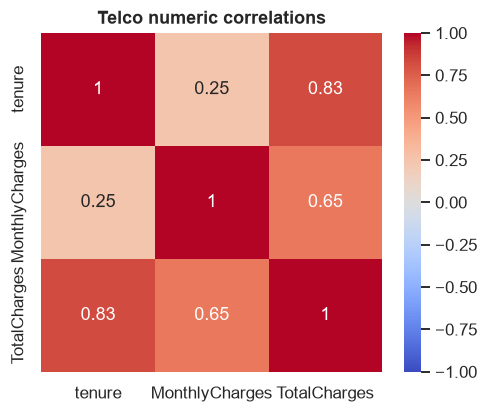

In [7]:
pair = shiller.dropna(subset=["Earnings", "SP500"])
print("Earnings vs SP500 price:")
print(eda.correlation_trio(pair, "Earnings", "SP500").round(3).to_string(index=False))

num = telco[["tenure", "MonthlyCharges", "TotalCharges"]]
fig, ax = plt.subplots(figsize=(5, 4))
import seaborn as sns
sns.heatmap(num.corr(), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Telco numeric correlations"); eda.savefig(fig, "p1_corr_heatmap.png"); plt.show()

In [8]:
from sklearn.feature_selection import mutual_info_classif
X = telco[["tenure", "MonthlyCharges", "TotalCharges"]]
mi = mutual_info_classif(X, telco.churn_flag, random_state=0)
pb = X.apply(lambda c: c.corr(telco.churn_flag))  # point-biserial (linear) for contrast
cmp = pd.DataFrame({"|pearson| vs churn": pb.abs().round(3), "mutual_info vs churn": np.round(mi, 3)})
print(cmp.to_string())
print("\ntenure carries the most information about churn; MI ranks dependence even when linear corr is modest.")

                |pearson| vs churn  mutual_info vs churn
tenure                       0.352                 0.074
MonthlyCharges               0.193                 0.051
TotalCharges                 0.198                 0.045

tenure carries the most information about churn; MI ranks dependence even when linear corr is modest.


### 6. Multicollinearity — VIF

Correlated predictors inflate coefficient variance and make models unstable. **VIF > 5** is
notable, **> 10** serious. `TotalCharges ≈ tenure × MonthlyCharges` by construction, so it lights up.

In [9]:
print(eda.vif_table(telco[["tenure", "MonthlyCharges", "TotalCharges"]]).round(2).to_string(index=False))
print("\nTotalCharges is near-redundant given tenure & MonthlyCharges -> drop one or combine.")

       feature  VIF
  TotalCharges 9.51
        tenure 5.84
MonthlyCharges 3.22

TotalCharges is near-redundant given tenure & MonthlyCharges -> drop one or combine.


### 7. Categorical association — chi-square & Cramér's V

Correlation is for numbers. For categoricals, **Cramér's V** ∈ [0, 1] measures association
(bias-corrected here). The churn-rate breakdown shows *why* `Contract` matters.

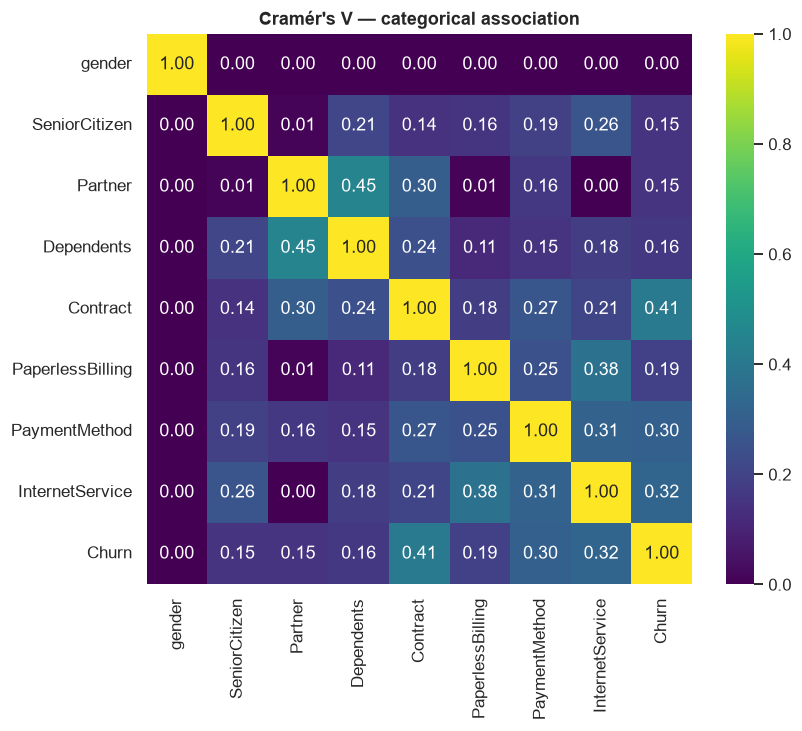

In [10]:
cats = ["gender", "SeniorCitizen", "Partner", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod", "InternetService", "Churn"]
cv = eda.cramers_v_matrix(telco, cats)
fig, ax = plt.subplots(figsize=(8, 6.5))
import seaborn as sns
sns.heatmap(cv, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Cramér's V — categorical association"); eda.savefig(fig, "p1_cramers_v.png"); plt.show()

In [11]:
rate = telco.groupby("Contract", observed=True).churn_flag.mean().sort_values(ascending=False)
print("Churn rate by contract type:")
print((rate * 100).round(1).astype(str).add("%").to_string())
v = cv.loc["Contract", "Churn"]
print(f"\nMonth-to-month churns ~43%; two-year ~3%. Contract is the strongest single driver (V={v:.2f} vs Churn).")

Churn rate by contract type:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%

Month-to-month churns ~43%; two-year ~3%. Contract is the strongest single driver (V=0.41 vs Churn).


### 8. Missing-data mechanisms — MCAR / MAR / MNAR

- **MCAR** — missingness independent of everything (safe to drop; rare).
- **MAR** — missingness depends on *observed* data (impute using the relationship).
- **MNAR** — missingness depends on the *unobserved* value itself (hardest; needs modelling).

Telco's `TotalCharges` is the textbook **MAR** case — re-derived from the raw file:

In [12]:
raw = data.load_telco_raw()
miss = pd.to_numeric(raw.TotalCharges, errors="coerce").isna()
print("missing TotalCharges:", int(miss.sum()))
print("their tenure values:", sorted(raw.loc[miss, "tenure"].unique().tolist()), "-> 100% at tenure 0")
print("\nMissingness is fully explained by an OBSERVED column (tenure) => MAR, not MCAR.")
print("Right fix: set 0 (no completed billing cycle). Wrong fix: blind mean-imputation, which invents history.")

missing TotalCharges: 11
their tenure values: [0] -> 100% at tenure 0

Missingness is fully explained by an OBSERVED column (tenure) => MAR, not MCAR.
Right fix: set 0 (no completed billing cycle). Wrong fix: blind mean-imputation, which invents history.


### Takeaways

- Distributions, not point summaries — the battery exposes skew, fat tails, bimodality.
- Returns have **excess kurtosis ≈ 17**: extreme events are routine, not anomalies.
- Outliers are questions; the worst returns are real crashes worth keeping.
- Use **Spearman/Kendall + MI** alongside Pearson; check **VIF** for redundancy.
- Categoricals → **Cramér's V**; `Contract` is the dominant churn driver.
- Always interrogate the **missingness mechanism** before imputing.

**Next — Part 2 (Time-Series Foundations):** index hygiene, decomposition (additive/multiplicative/STL),
stationarity (ADF × KPSS), ACF/PACF, differencing — on the S&P 500 series.